# Simple Linear Regression Model :- Pridicting sunday newspaper circulation based on weekly newspaper circulation


## Design and implement simple linear regression model to predict sunday newspaper
## circulation based on dialy newspaper circulation
## predict sunday paper circulation for 200, 300 and 500 dialy circulation
## Evaluate model with R-square and Adjusted R-Square

In [4]:
import pandas as pd
df_news=pd.read_csv("NewspaperData.csv")

In [5]:
df_news.head()

,Newspaper,daily,sunday
0,Baltimore Sun,391.952,488.506
1,Boston Globe,516.981,798.298
2,Boston Herald,355.628,235.084
3,Charlotte Observer,238.555,299.451
4,Chicago Sun Times,537.780,559.093


In [6]:
df_news.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Newspaper  34 non-null     str    
 1   daily      34 non-null     float64
 2   sunday     34 non-null     float64
dtypes: float64(2), str(1)
memory usage: 948.0 bytes


In [10]:
df_news.corr(numeric_only=True)

,daily,sunday
daily,1.000000,0.958154
sunday,0.958154,1.000000


In [15]:
import matplotlib.pyplot as plt

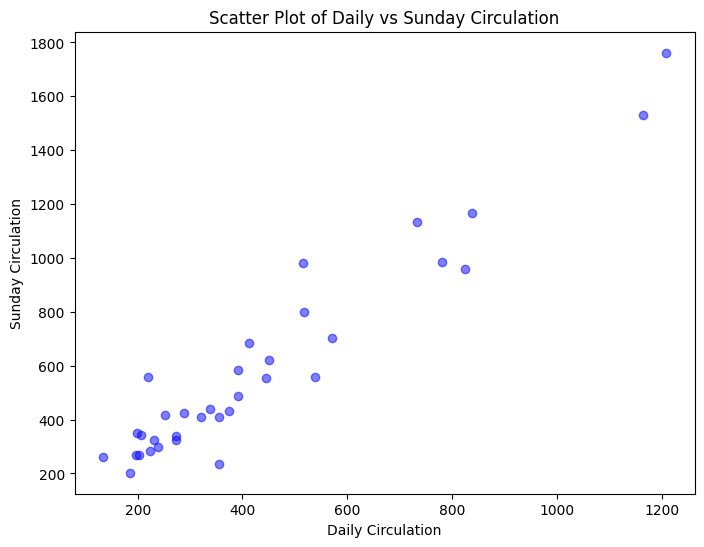

In [17]:
daily_data=df_news['daily']
sunday_data=df_news['sunday']
plt.figure(figsize=(8,6))
plt.scatter(daily_data, sunday_data, color='blue', alpha=0.5)
plt.title('Scatter Plot of Daily vs Sunday Circulation')
plt.xlabel('Daily Circulation')
plt.ylabel('Sunday Circulation')
#plt.grid(True)
plt.show()


In [18]:
df_news.head()

,Newspaper,daily,sunday
0,Baltimore Sun,391.952,488.506
1,Boston Globe,516.981,798.298
2,Boston Herald,355.628,235.084
3,Charlotte Observer,238.555,299.451
4,Chicago Sun Times,537.780,559.093


In [28]:
import sys
!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\MSI\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [29]:
import statsmodels.formula.api as smf

model = smf.ols("sunday ~ daily", data=df_news).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 sunday   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     358.5
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           6.02e-19
Time:                        21:07:22   Log-Likelihood:                -206.85
No. Observations:                  34   AIC:                             417.7
Df Residuals:                      32   BIC:                             420.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.8356     35.804      0.386      0.7

In [30]:
model.params

Intercept    13.835630
daily         1.339715
dtype: float64

In [31]:

print(f'model t-values:\n{model.tvalues}\n-----------------\nmodel p-values: \n{model.pvalues}')

model t-values:
Intercept     0.386427
daily        18.934840
dtype: float64
-----------------
model p-values: 
Intercept    7.017382e-01
daily        6.016802e-19
dtype: float64


In [32]:
model.rsquared

np.float64(0.9180596895873295)

In [33]:
model.rsquared,model.rsquared_adj

(np.float64(0.9180596895873295), np.float64(0.9154990548869336))

# R-squared

## R**2 tells us how well the model fits the data. Closer to 1=better fit
## Example: If R sqaure =0.91, the model explains 91% of the variation in y
## But R2 is quirk - it always increases when we add more features, even the useful ones

# Adjusted R-squared deals with this issue.

## Adjusted R² fixes this quirk by penalizing extra features that don’t help.

## Rule of thumb: If a feature doesn’t improve the model enough, Adjusted R² decreases.

## Watch how Adjusted R² changes when we add/remove features later!

In [34]:
newdata=pd.Series([200,300,500])
newdata

0    200
1    300
2    500
dtype: int64

In [36]:
data_pred=pd.DataFrame(newdata,columns=['daily'])
data_pred

,daily
0,200
1,300
2,500


In [37]:
model.predict(data_pred)

0    281.778581
1    415.750057
2    683.693009
dtype: float64

In [38]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 sunday   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     358.5
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           6.02e-19
Time:                        21:18:36   Log-Likelihood:                -206.85
No. Observations:                  34   AIC:                             417.7
Df Residuals:                      32   BIC:                             420.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.8356     35.804      0.386      0.702     -59.095      86.766
daily          1.3397      0.071     18.935      0.000       1.196       1.484
==============================================================================
Omnibus:                        3.297   Durbin-Watson:                   2.059
Prob(Omnibus):                  0.192   Jarque-Bera (JB):                1.990
Skew:                           0.396   Prob(JB):                        0.370
Kurtosis:                       3.882   Cond. No.                         965.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""